# Cliff Walking: Reward Engineering

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [61]:
import numpy as np
np.set_printoptions(precision=2)

In [62]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

from gym_classics.animation import gridworld_animate                               
from gym_classics.algorithms.policy import random_policy

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "



Note: The patched version of the `gym_classic` also contains this environment as 'CliffWalk-v1'.

In [63]:
gym_env = gym.make('LMaze-v0', tabular = True)
env = gym_env.unwrapped

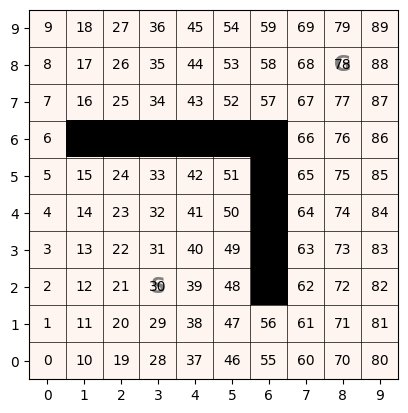

In [64]:
env.image()

## Learning 

We use here Q-Learning as an example. Initially, we have no idea where to go so the algorithm only explores. The question is:

> How fast does the algorithm learn from the reward signal?

This clearly depends on how the reward signal helps the algorithm to update its estimate of the Q-values.


### Reward Structure

We will look at several simple reward structures. To compare learning speed over different reward structures, we cannot use the return, but we will look at the episode length as an indication on how fast it finds the shortest path along the cliff (the optimal length is 13).

In [65]:
from gym_classics.algorithms.temporal_difference_learning import Q_learning
from gym_classics.performance import plot_returns

Reward structure with step cost. Step cost accumulation ends with the episode. 

Q-Learning:   0%|          | 0/100 [00:00<?, ?it/s]

Q-Learning: 100%|██████████| 100/100 [00:00<00:00, 318.52it/s]


Avg Episode Length: 140.84


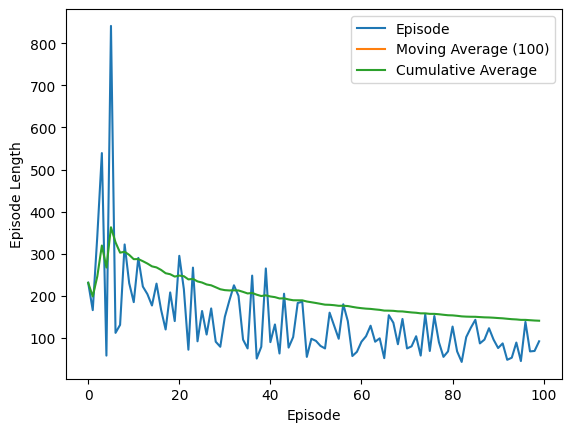

In [66]:
gym_env = gym.make('LMaze-v0', tabular = True, goal_reward = 0.0, step_reward = -1.0)
env = gym_env.unwrapped

Q, history = Q_learning(env, discount=1.0, alpha=.1, epsilon=.1, n = 100, history =True)

print(f"Avg Episode Length: {np.mean(history['ep_lens'])}")
plot_returns(history["ep_lens"], y_label = "Episode Length")


Reward finding the goal state, but no step cost.

Q-Learning: 100%|██████████| 100/100 [00:00<00:00, 292.21it/s]


Avg Episode Length: 108.45


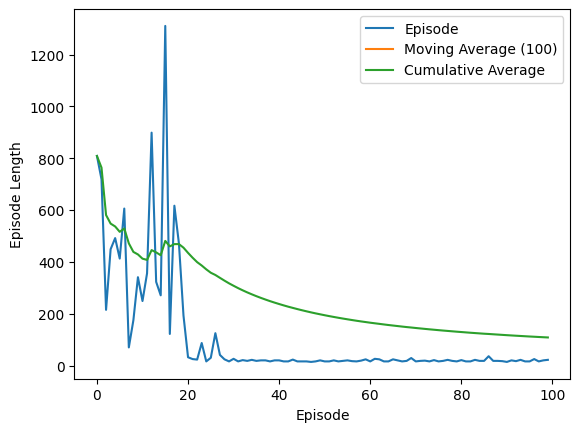

In [67]:
gym_env = gym.make('LMaze-v0', tabular = True, goal_reward = 1.0, step_reward = 0.0)
env = gym_env.unwrapped

Q, history = Q_learning(env, discount=1.0, alpha=.1, epsilon=.1, n = 100, history =True)

print(f"Avg Episode Length: {np.mean(history['ep_lens'])}")
plot_returns(history["ep_lens"], y_label = "Episode Length")

Reward for the goal state and very small step cost.

Q-Learning: 100%|██████████| 100/100 [00:00<00:00, 395.01it/s]


Avg Episode Length: 73.01


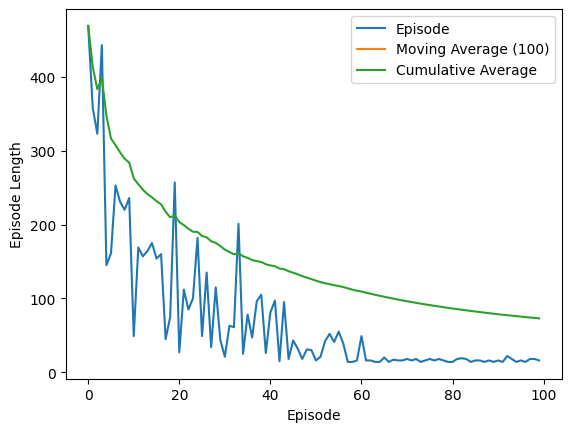

In [68]:
gym_env = gym.make('LMaze-v0', tabular = True, goal_reward = 1.0, step_reward = -0.0001)
env = gym_env.unwrapped

Q, history = Q_learning(env, discount=1, alpha=.1, epsilon=.1, n = 100, history =True)

print(f"Avg Episode Length: {np.mean(history['ep_lens'])}")
plot_returns(history["ep_lens"], y_label = "Episode Length")

### Reward Shaping: Potential-Based Reward Shaping

The potential of a state $\phi(s)$ indicates how promising a state is. Potential-based reward shaping adds the difference in potential
fro going from state $s$ to $s'$ to the reward.

$$F = R  + \gamma \phi(s') - \phi(s)$$

This approach does not change the optimal policy, but the potential can provide useful information for the agent.

For navigation tasks, the negative distance to the goal can be used since the potential increases when moving toward the goal. 
The potential acts as a heuristic like in A* search. 

In [69]:
import gymnasium as gym
import numpy as np

class PotentialRewardWrapper(gym.Wrapper):
    def __init__(self, env, discount = 1.0, potential_factor = 1.0):
        super().__init__(env)
        self.discount = discount
        self.potential_factor = potential_factor
        self._prev_state = None
    
    def potential(self, state):
        return -1.0 *np.linalg.norm(np.array(state) - np.array(list(self.env.unwrapped._goals)[0]))
    
    def step(self, action):
        # 1. Execute the step in the underlying environment
        obs, reward, terminated, truncated, info = self.env.step(action)
        next_state = self.env.state
        
        # 2. Access the next state/observation ('obs') to modify the reward
        modified_reward = reward + self.potential_factor * (self.discount * self.potential(next_state) - self.potential(self._prev_state))
        self._prev_state = next_state
        
        # 3. Return the standard tuple with your new reward
        return obs, modified_reward, terminated, truncated, info
    
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_state = self.env.state
        return obs, info

In [72]:
gym_env = gym.make('LMaze-v0', tabular = True, goal_reward = 1.0, step_reward = -0.0001)
env = PotentialRewardWrapper(gym_env.unwrapped, potential_factor = 0.001, discount = 1.0) 

Q-Learning: 100%|██████████| 100/100 [00:00<00:00, 104.72it/s]


Avg Episode Length: 82.11


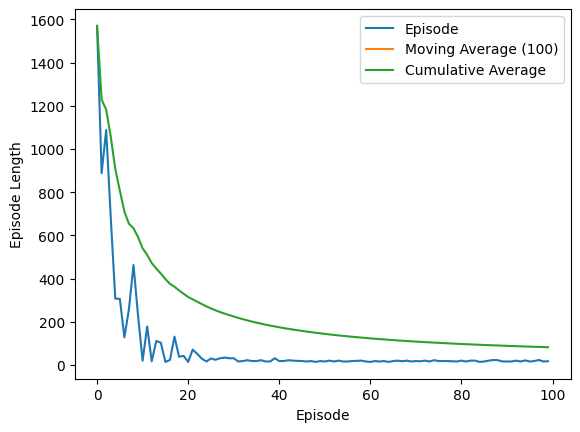

In [73]:
Q, history = Q_learning(env, discount=1, alpha=.1, epsilon=.1, n = 100, history =True)

print(f"Avg Episode Length: {np.mean(history['ep_lens'])}")
plot_returns(history["ep_lens"], y_label = "Episode Length")


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)